# Empirical study notebook

In [9]:
from decision_maker import *
from explainer import estimate_interventional_probability_tabular, PrototypeTabularExplainer
from fairlearn.datasets import fetch_acs_income, fetch_adult
import graphviz
from IPython.display import Image, display
import lime
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from utils import *
from xgboost import XGBClassifier

RANDOM_SEED = 42

## Loan Approval dataset

In [2]:
# Loan Approval dataset
loan_df = pd.read_csv("./LoanApproval.csv")
loan_df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [3]:
X_loan = loan_df.drop(columns=["loan_status"])
y_loan = loan_df["loan_status"]

loan_features = X_loan.columns.to_list()
X_train_loan, X_test_loan, y_train_loan, y_test_loan = train_test_split(X_loan, y_loan, test_size=0.2, random_state=RANDOM_SEED)

categorical_cols = X_loan.select_dtypes(include=['object']).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

preprocessor_loan = ColumnTransformer(transformers=[('cat', encoder, categorical_cols)], remainder='passthrough')

X_train_processed_loan = pd.DataFrame(preprocessor_loan.fit_transform(X_train_loan), columns=loan_features, index=X_train_loan.index)
X_test_processed_loan = pd.DataFrame(preprocessor_loan.transform(X_test_loan), columns=loan_features, index=X_test_loan.index)

loan_model1 = RandomForestClassifier(n_estimators=500, min_samples_leaf=5, max_features="sqrt", class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
loan_model1.fit(X_train_processed_loan, y_train_loan)
y_predict_loan = loan_model1.predict(X_test_processed_loan)

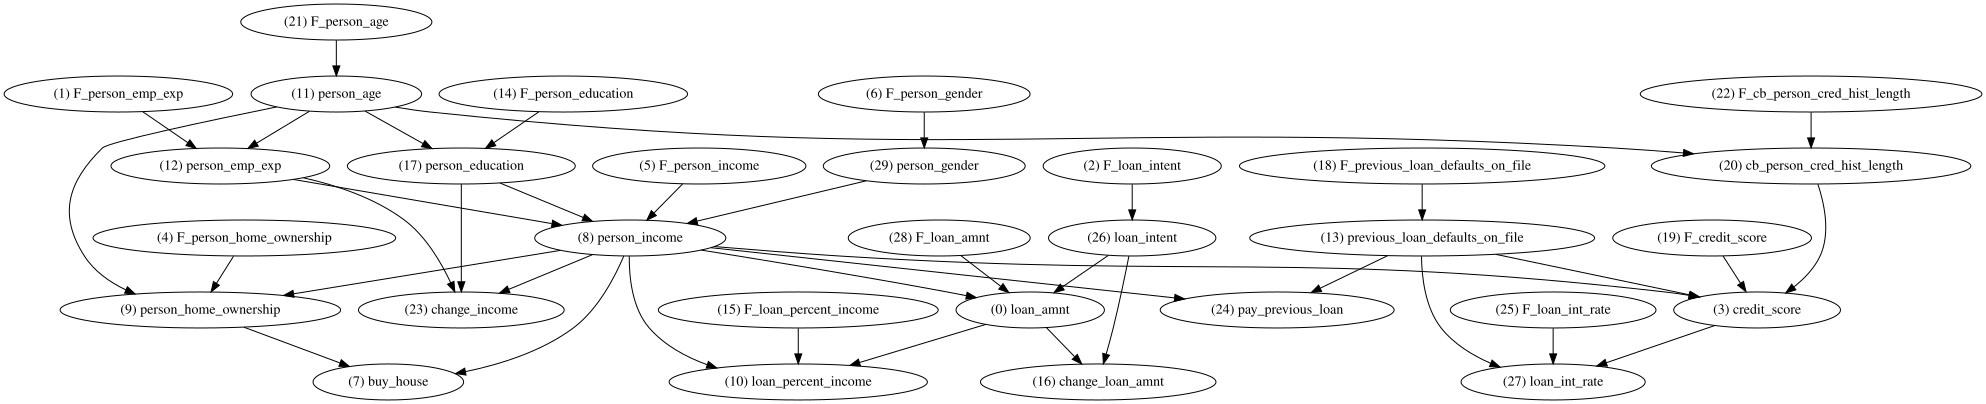

In [4]:
loan_actions = [
    "buy_house",
    "change_loan_amnt", 
    "change_income", 
    "pay_previous_loan"
]

loan_causal = CausalModel(features=loan_features, actions=loan_actions)

loan_causal.add_causal_edge("person_age", "person_emp_exp")
loan_causal.add_causal_edge("person_age", "cb_person_cred_hist_length")
loan_causal.add_causal_edge("person_age", "person_education")

loan_causal.add_causal_edge("person_education", "person_income")
loan_causal.add_causal_edge("person_emp_exp", "person_income")

loan_causal.add_causal_edge("person_income", "person_home_ownership")
loan_causal.add_causal_edge("person_age", "person_home_ownership")

loan_causal.add_causal_edge("cb_person_cred_hist_length", "credit_score")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "credit_score")
loan_causal.add_causal_edge("person_income", "credit_score")

loan_causal.add_causal_edge("loan_intent", "loan_amnt")
loan_causal.add_causal_edge("person_income", "loan_amnt")

loan_causal.add_causal_edge("loan_amnt", "loan_percent_income")
loan_causal.add_causal_edge("person_income", "loan_percent_income")

loan_causal.add_causal_edge("credit_score", "loan_int_rate")
loan_causal.add_causal_edge("previous_loan_defaults_on_file", "loan_int_rate")
#loan_causal.add_causal_edge("loan_percent_income", "loan_int_rate")
#loan_causal.add_causal_edge("person_home_ownership", "loan_int_rate")

loan_causal.add_causal_edge("person_gender", "person_income")

loan_causal.add_causal_edge("person_income", "buy_house")
loan_causal.add_causal_edge("person_home_ownership", "buy_house")

loan_causal.add_causal_edge("loan_amnt", "change_loan_amnt")
loan_causal.add_causal_edge("loan_intent", "change_loan_amnt")

loan_causal.add_causal_edge("person_income", "change_income")
loan_causal.add_causal_edge("person_education", "change_income")
loan_causal.add_causal_edge("person_emp_exp", "change_income")

loan_causal.add_causal_edge("previous_loan_defaults_on_file", "pay_previous_loan")
loan_causal.add_causal_edge("person_income", "pay_previous_loan")

dag = loan_causal.getDAG()
loan_dot = dag.toDot()
loan_graph = graphviz.Source(loan_dot)
display(loan_graph)

In [5]:
utility_matrix = np.array([[-12, 0], [-7, 0], [-12, 0], [-6, 0]])
prototype_explainer = PrototypeTabularExplainer(loan_model1, X_train_processed_loan, loan_features, loan_actions, loan_causal, utility_matrix, cognitive=())
x_instance = X_test_processed_loan.iloc[[0]]

In [6]:
prototype_explainer.explain_instance(x_instance)
loan_model1_explanations = pd.DataFrame(prototype_explainer.extract_explanation())
display(loan_model1_explanations)

,features,prediction probability,utility score,preferrable action,information score
0,{'person_home_ownership'},"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,"{'person_home_ownership', 'loan_int_rate'}","[0.7443560687421075, 0.2556439312578997]",-4.466136,pay_previous_loan,0.568451
2,{'loan_int_rate'},"[0.7450707747371473, 0.25492922526285733]",-4.470425,pay_previous_loan,0.567686
3,"{'person_home_ownership', 'loan_percent_income'}","[0.8208446315718143, 0.17915536842818183]",-4.925068,pay_previous_loan,0.470110
4,{'loan_percent_income'},"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184
5,"{'person_home_ownership', 'loan_percent_income...","[0.8337975329317087, 0.16620246706828906]",-5.002785,pay_previous_loan,0.449813
6,"{'loan_int_rate', 'loan_percent_income'}","[0.8358476689730484, 0.16415233102695512]",-5.015086,pay_previous_loan,0.446492


In [7]:
loan_model1_attribution = pd.DataFrame(prototype_explainer.extract_attribution(x_instance))
display(loan_model1_attribution)

,features,prediction probability,utility score,preferrable action,information score
0,person_home_ownership,"[0.7329098768834578, 0.2670901231165461]",-4.397459,pay_previous_loan,0.580343
1,loan_int_rate,"[0.7450707747371473, 0.2549292252628573]",-4.470425,pay_previous_loan,0.567686
2,loan_percent_income,"[0.8227592877731847, 0.1772407122268218]",-4.936556,pay_previous_loan,0.467184
3,person_gender,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
4,person_education,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
5,person_income,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
6,person_emp_exp,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
7,loan_intent,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
8,cb_person_cred_hist_length,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745
9,credit_score,"[0.9264424915379204, 0.0735575084620796]",-5.558655,pay_previous_loan,0.262745


### Empirical comparison

#### Robustness study

/home/alexis/anaconda3/lib/python3.13/site-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/anaconda3/lib/python3.13/site-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/home/alexis/anaconda3/lib/python3.13/site-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To a

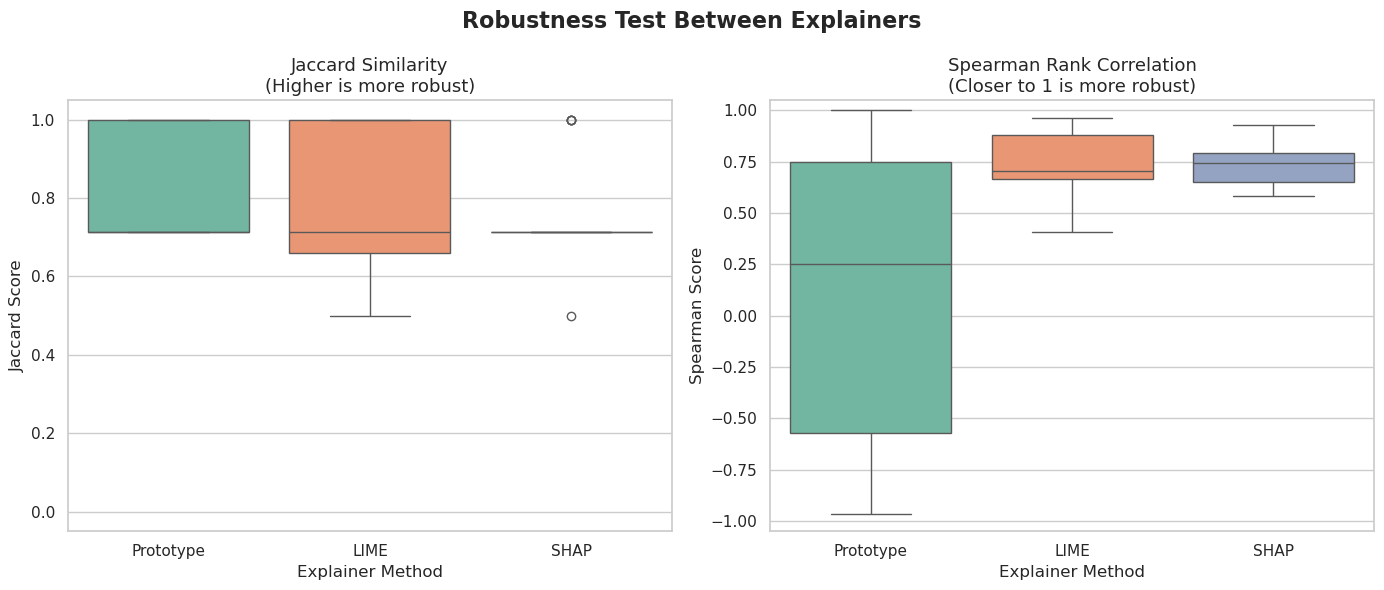

In [8]:
dynamic_class_names = [str(c) for c in sorted(loan_df['loan_status'].unique())]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed_loan.values,
    feature_names=loan_features,
    class_names=dynamic_class_names, 
    mode='classification'
)

shap_explainer = shap.Explainer(loan_model1)

tester = ExplainerTester(
    model=loan_model1,
    features=loan_features,
    actions=loan_actions,
    causal_model=loan_causal,
    utility_matrix=utility_matrix,
    X_train=X_train_processed_loan,
    X_test=X_test_processed_loan,
    lime_explainer=lime_explainer,
    shap_explainer=shap_explainer,
    n_samples=20 
)

causal_data, lime_data, shap_data = tester.primary_test(display=True)

/tmp/ipykernel_235337/300857262.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_235337/300857262.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


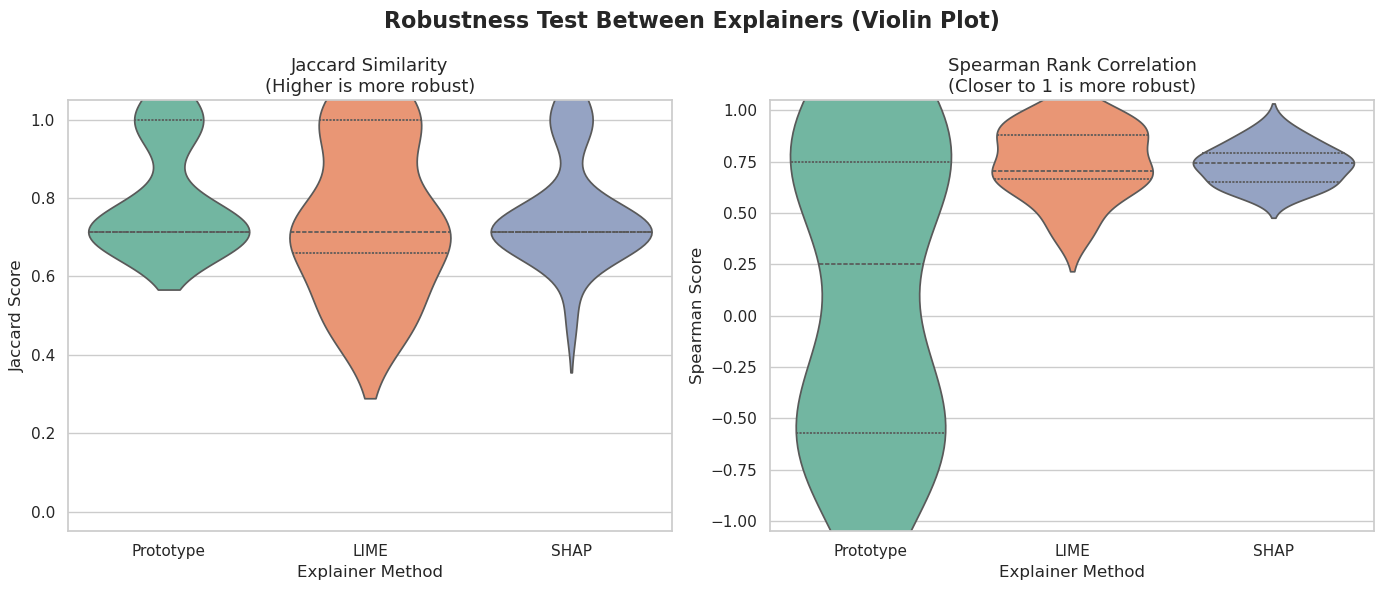

In [11]:
data_list = []
for i in range(20):
    data_list.append({"Explainer": "Prototype", "Metric": "Jaccard", "Score": causal_data["jaccard"][i]})
    data_list.append({"Explainer": "LIME", "Metric": "Jaccard", "Score": lime_data["jaccard"][i]})
    data_list.append({"Explainer": "SHAP", "Metric": "Jaccard", "Score": shap_data["jaccard"][i]})
                
    data_list.append({"Explainer": "Prototype", "Metric": "Spearman", "Score": causal_data["spearman"][i]})
    data_list.append({"Explainer": "LIME", "Metric": "Spearman", "Score": lime_data["spearman"][i]})
    data_list.append({"Explainer": "SHAP", "Metric": "Spearman", "Score": shap_data["spearman"][i]})
                
df = pd.DataFrame(data_list)
            
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Robustness Test Between Explainers (Violin Plot)", fontsize=16, fontweight="bold")
            
sns.violinplot(
    data=df[df["Metric"] == "Jaccard"], 
    x="Explainer", y="Score", 
    ax=axes[0], palette="Set2", inner="quartile"
)
axes[0].set_title("Jaccard Similarity\n(Higher is more robust)", fontsize=13)
axes[0].set_ylabel("Jaccard Score", fontsize=12)
axes[0].set_xlabel("Explainer Method", fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
            
sns.violinplot(
    data=df[df["Metric"] == "Spearman"], 
    x="Explainer", y="Score", 
    ax=axes[1], palette="Set2", inner="quartile"
)
axes[1].set_title("Spearman Rank Correlation\n(Closer to 1 is more robust)", fontsize=13)
axes[1].set_ylabel("Spearman Score", fontsize=12)
axes[1].set_xlabel("Explainer Method", fontsize=12)
axes[1].set_ylim(-1.05, 1.05)
            
plt.tight_layout()
plt.show()

In [ ]:
data_list = []
for i in range(20):
    data_list.append({"Explainer": "Prototype", "Metric": "Jaccard", "Score": causal_data["jaccard"][i]})
    data_list.append({"Explainer": "LIME", "Metric": "Jaccard", "Score": lime_data["jaccard"][i]})
    data_list.append({"Explainer": "SHAP", "Metric": "Jaccard", "Score": shap_data["jaccard"][i]})
                
    data_list.append({"Explainer": "Prototype", "Metric": "Spearman", "Score": causal_data["spearman"][i]})
    data_list.append({"Explainer": "LIME", "Metric": "Spearman", "Score": lime_data["spearman"][i]})
    data_list.append({"Explainer": "SHAP", "Metric": "Spearman", "Score": shap_data["spearman"][i]})
                
df = pd.DataFrame(data_list)
            
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Robustness Test Between Explainers (Violin Plot)", fontsize=16, fontweight="bold")
            
sns.barplot(
    data=df[df["Metric"] == "Jaccard"], 
    x="Explainer", y="Score", 
    ax=axes[0], palette="Set2",
    errorbar="sd", capsize=0.1
)
axes[0].set_title("Jaccard Similarity\n(Higher is more robust)", fontsize=13)
axes[0].set_ylabel("Jaccard Score", fontsize=12)
axes[0].set_xlabel("Explainer Method", fontsize=12)
axes[0].set_ylim(-0.05, 1.05)
            
sns.barplot(
    data=df[df["Metric"] == "Spearman"], 
    x="Explainer", y="Score", 
    ax=axes[1], palette="Set2",
    errorbar="sd", capsize=0.1
)
axes[1].set_title("Spearman Rank Correlation\n(Closer to 1 is more robust)", fontsize=13)
axes[1].set_ylabel("Spearman Score", fontsize=12)
axes[1].set_xlabel("Explainer Method", fontsize=12)
axes[1].set_ylim(-1.05, 1.05)
            
plt.tight_layout()
plt.show()

## Adult Income dataset

In [ ]:
X, y = shap.datasets.adult()

In [ ]:
X.columns

In [ ]:
adult_features = X.columns.to_list()

adult_actions = [
    'pursue_higher_education',
    'change_occupation',
    'adjust_working_hours',
    'make_investment'
]

adult_causal = CausalModel(features=adult_features, actions=adult_actions)

adult_causal.add_causal_edge('Age', 'Education-Num')
adult_causal.add_causal_edge('Age', 'Marital Status')
adult_causal.add_causal_edge('Age', 'Hours per week')

adult_causal.add_causal_edge('Country', 'Education-Num')
adult_causal.add_causal_edge('Race', 'Education-Num')
adult_causal.add_causal_edge('Sex', 'Occupation')

adult_causal.add_causal_edge('Education-Num', 'Occupation')
adult_causal.add_causal_edge('Education-Num', 'Workclass')

adult_causal.add_causal_edge('Marital Status', 'Relationship')

adult_causal.add_causal_edge('Occupation', 'Hours per week')
adult_causal.add_causal_edge('Occupation', 'Capital Gain')
adult_causal.add_causal_edge('Occupation', 'Capital Loss')

adult_causal.add_causal_edge('Race', 'Workclass')

adult_causal.add_causal_edge('Workclass', 'Hours per week')

adult_causal.add_causal_edge('Age', 'pursue_higher_education')
adult_causal.add_causal_edge('Education-Num', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital Gain', 'pursue_higher_education')
adult_causal.add_causal_edge('Capital Loss', 'pursue_higher_education')

adult_causal.add_causal_edge('Occupation', 'change_occupation')
adult_causal.add_causal_edge('Education-Num', 'change_occupation')
adult_causal.add_causal_edge('Workclass', 'change_occupation')
adult_causal.add_causal_edge('Capital Gain', 'change_occupation')

adult_causal.add_causal_edge('Hours per week', 'adjust_working_hours')
adult_causal.add_causal_edge('Marital Status', 'adjust_working_hours')
adult_causal.add_causal_edge('Relationship', 'adjust_working_hours')

adult_causal.add_causal_edge('Capital Gain', 'make_investment')
adult_causal.add_causal_edge('Capital Loss', 'make_investment')
adult_causal.add_causal_edge('Education-Num', 'make_investment')

dag = adult_causal.getDAG()
adult_dot = dag.toDot()
adult_graph = graphviz.Source(adult_dot)

display(adult_graph)

## Diabetes dataset

In [ ]:
X, y = shap.datasets.california()
X

In [ ]:
y

## Iris dataset